In [1]:
import xarray
from pyproj import Transformer
import numpy as np
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

from tqdm import tqdm

import torch
from torch.utils.data import DataLoader, TensorDataset

import presto
from presto.dataops.dataset import (
    FranceCropsFullDataset,
)


# this is to silence the xarray deprecation warning.
# Our version of xarray is pinned, but we'll need to fix this
# when we upgrade
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

/home/p.kuznetsov/presto/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2. Using Presto as a feature extractor for a random forest

One way to use Presto is as a feature extractor for a simple model (e.g. a Random Forest). We do this below.

In [2]:
batch_size = 64

state_dict = torch.load("/home/p.kuznetsov/presto/output/2025_05_09_20_53_12_590014/models/36.pt")
pretrained_model = presto.Presto.construct(max_sequence_length=60)
pretrained_model.load_state_dict(state_dict=state_dict)
pretrained_model.eval()

Presto(
  (encoder): Encoder(
    (eo_patch_embed): ModuleDict(
      (S2_B1): Linear(in_features=1, out_features=128, bias=True)
      (S2_RGB): Linear(in_features=3, out_features=128, bias=True)
      (S2_Red_Edge): Linear(in_features=3, out_features=128, bias=True)
      (S2_NIR_10m): Linear(in_features=1, out_features=128, bias=True)
      (S2_NIR_20m): Linear(in_features=1, out_features=128, bias=True)
      (S2_NIR_60m): Linear(in_features=1, out_features=128, bias=True)
      (S2_SWIR): Linear(in_features=2, out_features=128, bias=True)
      (NDVI): Linear(in_features=1, out_features=128, bias=True)
    )
    (blocks): ModuleList(
      (0-1): 2 x Block(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=128, out_

We will start by constructing features for the training data, and using this to train a Random Forest.

In [ ]:
train_data = FranceCropsFullDataset(
    dataset="saget-antoine/francecrops",
    split="test",
    shuffle=True,
    seed=42,
    cache_dir="./cache_test_full",
    test_ratio=0.05,
    val_ratio=0.05
)

In [4]:
from collections import defaultdict
from torch.utils.data import Subset
import random

def stratified_split(dataset, n_per_class):
    label_to_indices = defaultdict(list)

    # Group indices by class label
    for idx in range(len(dataset)):
        label = dataset[idx]["y"].item()
        label_to_indices[label].append(idx)

    train_indices = []
    test_indices = []

    for label, indices in label_to_indices.items():
        if len(indices) < n_per_class:
            raise ValueError(f"Not enough samples for class {label}. Needed {n_per_class}, found {len(indices)}.")
        
        random.shuffle(indices)
        train_indices.extend(indices[:n_per_class])
        test_indices.extend(indices[n_per_class:])

    train_dataset = Subset(dataset, train_indices)
    test_dataset = Subset(dataset, test_indices)

    return train_dataset, test_dataset


In [5]:
N = 25  # Number of samples per class for training
train_dataset, test_dataset = stratified_split(train_data, N * 100)

In [6]:
dl = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,
)

In [7]:
features_list = []
labels = []
for entry in tqdm(dl):
    with torch.no_grad():
        x = entry["x"]
        mask = entry["mask"]
        encodings = (
            pretrained_model.encoder(
                x, mask=mask,
            )
            .cpu()
            .numpy()
        )
        features_list.append(encodings)
        labels.append(entry["y"].cpu().numpy())
features_np = np.concatenate(features_list)

100%|█████████████████████████████████████████████████████████████████████████████████| 782/782 [08:42<00:00,  1.50it/s]


In [8]:
all_labels = torch.cat([batch["y"] for batch in dl], dim=0)
labels = all_labels.cpu().numpy()

We use `features_np` to train a Random Forest classifier:

In [9]:
model = RandomForestClassifier(class_weight="balanced", random_state=42)
model.fit(features_np, labels)

RandomForestClassifier(class_weight='balanced', random_state=42)

We can then use this trained random forest to make some predictions on the test data.

In [10]:
dl_test = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

In [11]:
test_preds = []
test_labels = []
for entry in tqdm(dl_test):
    with torch.no_grad():
        pretrained_model.eval()
        x = entry["x"]
        mask = entry["mask"]
        encodings = (pretrained_model.encoder(
            x, mask=mask)
            .cpu()
            .numpy()
        )
        test_preds.append(model.predict_proba(encodings))
        test_labels.append(entry["y"].cpu().numpy())

  0%|                                                                                           | 0/782 [00:00<?, ?it/s]

100%|█████████████████████████████████████████████████████████████████████████████████| 782/782 [08:55<00:00,  1.46it/s]


In [12]:
test_labels_np = np.concatenate(test_labels)

In [13]:
test_preds_np = np.concatenate(test_preds)
test_preds_np = np.argmax(test_preds_np, axis=1)

In [14]:
from sklearn.metrics import classification_report
print(classification_report(test_labels_np, test_preds_np, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92      2500
           1       0.93      0.91      0.92      2500
           2       0.94      0.91      0.93      2500
           3       0.95      0.98      0.97      2500
           4       0.96      0.98      0.97      2500
           5       0.95      0.93      0.94      2500
           6       0.93      0.92      0.92      2500
           7       0.91      0.95      0.93      2500
           8       0.91      0.93      0.92      2500
           9       0.94      0.90      0.92      2500
          10       0.80      0.95      0.87      2500
          11       0.95      0.91      0.93      2500
          12       0.96      0.95      0.95      2500
          13       0.92      0.92      0.92      2500
          14       0.91      0.92      0.92      2500
          15       0.92      0.91      0.92      2500
          16       0.93      0.92      0.93      2500
          17       0.93    

In [4]:
full_dl = DataLoader(train_data, batch_size=batch_size, shuffle=False)

In [5]:
all_feats = []
all_labels = []

pretrained_model.eval()
with torch.no_grad():
    for batch in tqdm(full_dl):
        x    = batch["x"]
        mask = batch["mask"]
        y    = batch["y"]
        # run once through encoder
        feat = pretrained_model.encoder(x, mask=mask)  # [B, D]
        all_feats.append(feat.cpu().numpy())
        all_labels.append(y.cpu().numpy())

# stack into single arrays
X_full = np.concatenate(all_feats, axis=0)
y_full = np.concatenate(all_labels, axis=0)

100%|███████████████████████████████████████████████████████████████████████████████| 1563/1563 [18:41<00:00,  1.39it/s]


In [6]:
import numpy as np
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
from sklearn.metrics import classification_report
import pandas as pd

num_samples = X_full.shape[0]
all_idx     = np.arange(num_samples)
class_counts = Counter(y_full)
min_count    = min(class_counts.values())

def draw_indices_per_class(y, N, random_state=42):
    """
    Return indices for training set with N samples per class.
    Will raise ValueError if N > available for any class.
    """
    rng = np.random.RandomState(random_state)
    parts = []
    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        if len(cls_idx) < N:
            raise ValueError(f"Class {cls} only has {len(cls_idx)} samples, requested {N}")
        parts.append(rng.choice(cls_idx, size=N, replace=False))
    return np.concatenate(parts)

records = []

# Try different N values (samples per class)
for N in [1, 3, 5, 10, 25, 50, 75, 100, 125, 150, 175, 200]:
    N *= 100
    if N > min_count:
        print(f"⛔ stopping: smallest class has only {min_count} samples, cannot do N={N}.")
        break

    try:
        train_idx = draw_indices_per_class(y_full, N)
    except ValueError as e:
        print(f"⚠️ {e}")
        continue

    test_idx = np.setdiff1d(all_idx, train_idx, assume_unique=True)
    if len(test_idx) == 0:
        print(f"⚠️ Skipping N={N}: no test data left.")
        continue

    X_train, y_train = X_full[train_idx], y_full[train_idx]
    X_test,  y_test  = X_full[test_idx],  y_full[test_idx]

    # Train
    clf = RandomForestClassifier(class_weight="balanced", random_state=42)
    clf.fit(X_train, y_train)

    # Evaluate
    y_pred = clf.predict(X_test)
    rpt = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    records.append({
        "N": N,
        "train_size": len(y_train),
        "test_size": len(y_test),
        "accuracy": rpt["accuracy"],
        "precision_macro": rpt["macro avg"]["precision"],
        "recall_macro":    rpt["macro avg"]["recall"],
        "f1_macro":        rpt["macro avg"]["f1-score"],
        "precision_weighted": rpt["weighted avg"]["precision"],
        "recall_weighted":    rpt["weighted avg"]["recall"],
        "f1_weighted":        rpt["weighted avg"]["f1-score"],
    })

# Final DataFrame
df = pd.DataFrame(records)
print(df)


⚠️ Skipping N=5000: no test data left.
⛔ stopping: smallest class has only 5000 samples, cannot do N=7500.
      N  train_size  test_size  accuracy  precision_macro  recall_macro  \
0   100        2000      98000  0.684612         0.688243      0.684612   
1   300        6000      94000  0.800106         0.803519      0.800106   
2   500       10000      90000  0.845178         0.847825      0.845178   
3  1000       20000      80000  0.887138         0.889392      0.887137   
4  2500       50000      50000  0.929060         0.930444      0.929060   

   f1_macro  precision_weighted  recall_weighted  f1_weighted  
0  0.682448            0.688243         0.684612     0.682448  
1  0.799762            0.803519         0.800106     0.799762  
2  0.845251            0.847825         0.845178     0.845251  
3  0.887374            0.889392         0.887138     0.887374  
4  0.929271            0.930444         0.929060     0.929271  


In [ ]:
df['N'] = df['N'] / 100
df['train_size'] = df['train_size'] / 100
df['test_size'] = df['test_size'] / 100

In [ ]:
df.to_csv("rf_results.csv", index=False)

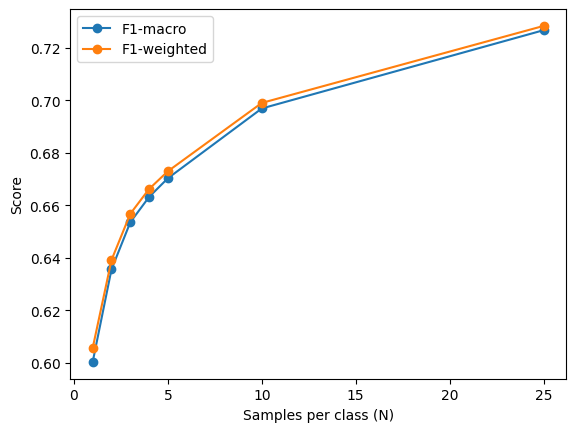

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df["N"], df["f1_macro"], marker="o", label="F1-macro")
plt.plot(df["N"], df["accuracy"], marker="o", label="F1-weighted")
# plt.xscale("log")
plt.xlabel("Samples per class (N)")
plt.ylabel("Score")
plt.legend()
plt.show()

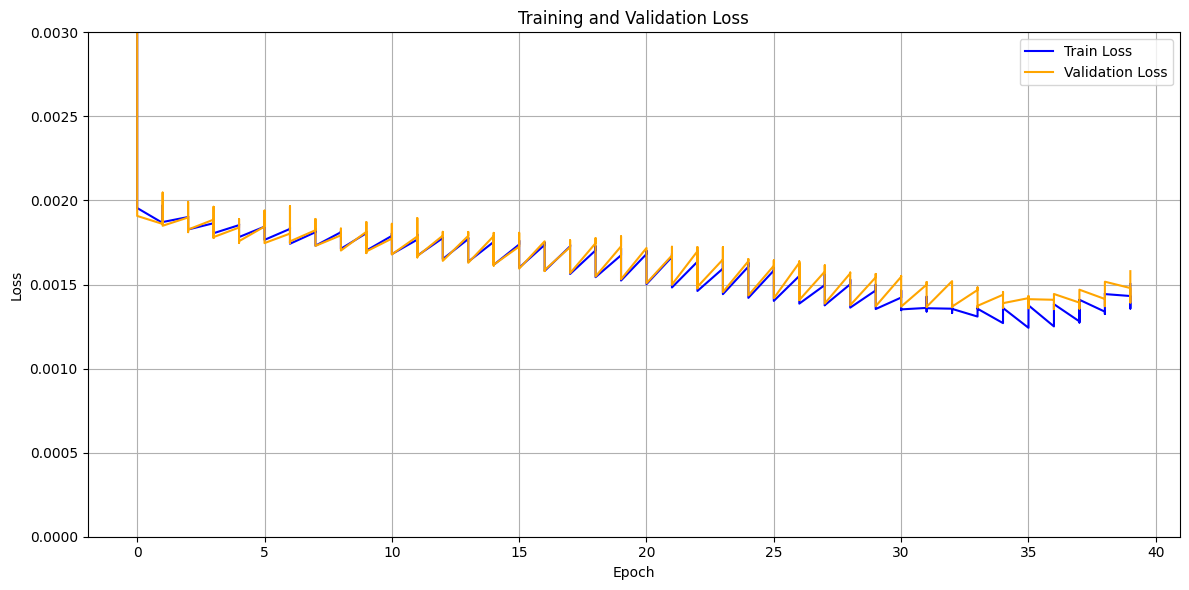

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV file
df = pd.read_csv('metrics.csv')

# Plot training and validation loss
plt.figure(figsize=(12, 6))

field = "Epoch"

plt.plot(df[field.lower()], df['train_loss'], label='Train Loss', color='blue')
plt.plot(df[field.lower()], df['val_loss'], label='Validation Loss', color='orange')
plt.xlabel(field)
plt.ylabel('Loss')
plt.ylim(0, 0.003)
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
